In [9]:
pip install fredapi

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import os
from fredapi import Fred as fred
from dotenv import load_dotenv

In [11]:
load_dotenv()
api_key = os.getenv('FRED_API_KEY')
fred = fred(api_key=api_key)

In [12]:
fred.get_series('GDP')

1946-01-01          NaN
1946-04-01          NaN
1946-07-01          NaN
1946-10-01          NaN
1947-01-01      243.164
                ...    
2025-01-01    30042.113
2025-04-01    30485.729
2025-07-01    31098.027
2025-10-01    31422.526
2026-01-01    31865.721
Length: 321, dtype: float64

In [13]:
df_property = pd.DataFrame(fred.get_series('QCZR368BIS'))
df_property
df_gdp = pd.DataFrame(fred.get_series('CLVMNACSCAB1GQCZ'))
df_gdp

,0
1995-01-01,667733.3
1995-04-01,680515.6
1995-07-01,689100.0
1995-10-01,693939.8
1996-01-01,706035.4
...,...
2025-01-01,1309700.5
2025-04-01,1315592.5
2025-07-01,1326218.3
2025-10-01,1335717.0


In [14]:
df_property_norm = df_property.copy()
df_property_norm['PropertyPrices_norm'] = (
    df_property_norm[0] - df_property_norm[0].min()
) / (df_property_norm[0].max() - df_property_norm[0].min())

df_gdp_norm = df_gdp.copy()
df_gdp_norm['GDP_norm'] = (
    df_gdp_norm[0] - df_gdp_norm[0].min()
) / (df_gdp_norm[0].max() - df_gdp_norm[0].min())

merged_normalized = pd.merge(
    df_property_norm[['PropertyPrices_norm']],
    df_gdp_norm[['GDP_norm']],
    left_index=True,
    right_index=True,
    how='inner'
)

merged_normalized

,PropertyPrices_norm,GDP_norm
2009-01-01,0.442253,0.471113
2009-04-01,0.241372,0.463876
2009-07-01,0.211543,0.470034
2009-10-01,0.196519,0.469847
2010-01-01,0.255132,0.481418
...,...,...
2024-10-01,0.590868,0.943860
2025-01-01,0.641411,0.957510
2025-04-01,0.669401,0.966298
2025-07-01,0.675921,0.982146


In [15]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [16]:
import matplotlib.pyplot as plt

<Axes: >

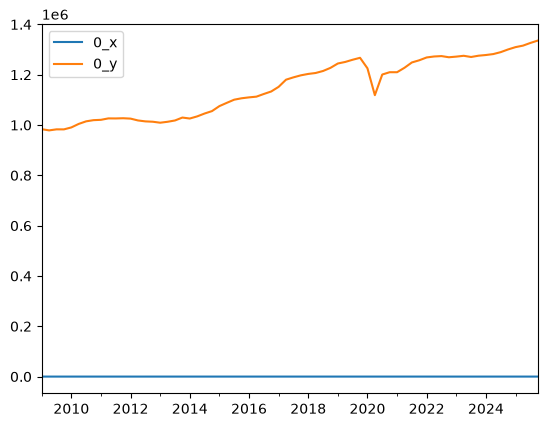

In [17]:
pd.merge(df_property, df_gdp, left_index=True, right_index=True).plot()

In [18]:
df.columns = ['PropertyPrices']
df.plot.line()
plt.title('Property Prices Over Time')
plt.show()

NameError: name 'df' is not defined

In [ ]:
df_gdp.columns = ['GDP']
df_gdp.plot.line()
plt.title('GDP Over Time')
plt.show()

In [ ]:
merged_normalized.plot()

In [19]:
from IPython.display import HTML, display

search = input("Search for a FRED series: ")
search_results = pd.DataFrame(fred.search(search))

if search_results.empty:
    print("No results found.")
else:
    display(
        HTML(
            "<div style='max-height: 400px; overflow: auto; border: 1px solid #ddd; padding: 8px;'>"
            + search_results.to_html(index=False, escape=False)
            + "</div>"
        )
    )


id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
GFDEGDQ188S,2026-07-13,2026-07-13,Federal Debt: Total Public Debt as Percent of Gross Domestic Product,1966-01-01,2026-01-01,Quarterly,Q,Percent of GDP,% of GDP,Seasonally Adjusted,SA,2026-06-25 08:01:21-05:00,85,"Federal Debt: Total Public Debt as Percent of Gross Domestic Product (GFDEGDQ188S) (https://fred.stlouisfed.org/series/GFDEGDQ188S) was first constructed by the Federal Reserve Bank of St. Louis in October 2012. It is calculated using Federal Government Debt: Total Public Debt (GFDEBTN) (https://fred.stlouisfed.org/series/GFDEBTN) and Gross Domestic Product, 1 Decimal (GDP) (https://fred.stlouisfed.org/series/GDP): GFDEGDQ188S = ((GFDEBTN/1000)/GDP)*100 GFDEBTN/1000 transforms GFDEBTN from millions of dollars to billions of dollars."
FYFSGDA188S,2026-07-13,2026-07-13,Federal Surplus or Deficit [-] as Percent of Gross Domestic Product,1929-01-01,2025-01-01,Annual,A,Percent of GDP,% of GDP,Not Seasonally Adjusted,NSA,2026-04-09 08:07:35-05:00,73,Federal Surplus or Deficit [-] as Percent of Gross Domestic Product (FYFSGDA188S) (https://fred.stlouisfed.org/series/FYFSGDA188S) was first constructed by the Federal Reserve Bank of St. Louis in October 2012. It is calculated using Federal Surplus or Deficit [-] (FYFSD) (https://fred.stlouisfed.org/series/FYFSD) and Gross Domestic Product (GDPA) (https://fred.stlouisfed.org/series/GDPA): FYFSGDA188S = ((FYFSD/1000)/GDPA)*100 FYFSD/1000 transforms FYFSD from millions of dollars to billions of dollars.
FYFSDFYGDP,2026-07-13,2026-07-13,Federal Surplus or Deficit [-] as Percent of Gross Domestic Product,1930-06-30,2025-09-30,"Annual, Fiscal Year",A,Percent of GDP,% of GDP,Not Seasonally Adjusted,NSA,2026-04-03 12:14:26-05:00,50,NaN
GDP,2026-07-13,2026-07-13,Gross Domestic Product,1947-01-01,2026-01-01,Quarterly,Q,Billions of Dollars,Bil. of $,Seasonally Adjusted Annual Rate,SAAR,2026-06-25 07:50:52-05:00,92,"BEA Account Code: A191RC Gross domestic product (GDP), the featured measure of U.S. output, is the market value of the goods and services produced by labor and property located in the United States.For more information, see the Guide to the National Income and Product Accounts of the United States (NIPA) and the Bureau of Economic Analysis (http://www.bea.gov/national/pdf/nipaguid.pdf)."
FYFRGDA188S,2026-07-13,2026-07-13,Federal Receipts as Percent of Gross Domestic Product,1929-01-01,2025-01-01,Annual,A,Percent of GDP,% of GDP,Not Seasonally Adjusted,NSA,2026-04-09 08:05:43-05:00,63,Federal Receipts as Percent of Gross Domestic Product (FYFRGDA188S) (https://fred.stlouisfed.org/series/FYFRGDA188S) was first constructed by the Federal Reserve Bank of St. Louis in January 2013. It is calculated using Federal Receipts (FYFR) (https://fred.stlouisfed.org/series/FYFR) and Gross Domestic Product (GDPA) (https://fred.stlouisfed.org/series/GDPA): FYFRGDA188S = ((FYFR/1000)/GDPA)*100 FYFR/1000 transforms FYFR from millions of dollars to billions of dollars.
FYONGDA188S,2026-07-13,2026-07-13,Federal Net Outlays as Percent of Gross Domestic Product,1929-01-01,2025-01-01,Annual,A,Percent of GDP,% of GDP,Not Seasonally Adjusted,NSA,2026-04-09 08:07:16-05:00,63,Federal Net Outlays as Percent of Gross Domestic Product (FYONGDA188S) (https://fred.stlouisfed.org/series/FYONGDA188S) was first constructed by the Federal Reserve Bank of St. Louis in January 2013. It is calculated using Federal Net Outlays (FYONET) (https://fred.stlouisfed.org/series/FYONET) and Gross Domestic Product (GDPA) (https://fred.stlouisfed.org/series/GDPA): FYONGDA188S = ((FYONET/1000)/GDPA)*100 FYONET/1000 transforms FYONET from millions of dollars to billions of dollars.
FYOIGDA188S,2026-07-13,2026-07-13,Federal Outlays: Interest as Percent of Gross Domestic Product,1940-01-01,2025-01-01,Annual,A,Percent of GDP,% of GDP,Not Seaso

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

series_id_w = widgets.Text(value='GDP', description='Series ID:')
units_w = widgets.Dropdown(
    options=[('Default', ''), ('Percent change', 'pc1'), ('Change', 'chg'), ('Level', 'lin')],
    description='Units'
)
aggregation_w = widgets.Dropdown(
    options=[('Default', ''), ('Average', 'avg'), ('Sum', 'sum'), ('End of period', 'eop')],
    description='Aggregation'
)
frequency_w = widgets.Dropdown(
    options=[('Default', ''), ('Daily', 'd'), ('Weekly', 'w'), ('Monthly', 'm'), ('Quarterly', 'q'), ('Annual', 'a')],
    description='Frequency'
)
seasonal_w = widgets.Dropdown(
    options=[('Default', ''), ('Seasonally adjusted', 'sa'), ('Not seasonally adjusted', 'notseasonal')],
    description='Seasonal adj.'
)
output = widgets.Output()


def fetch_series(_):
    with output:
        output.clear_output(wait=True)
        params = {}
        for name, widget in [
            ('units', units_w),
            ('aggregation_method', aggregation_w),
            ('frequency', frequency_w),
            ('seasonal_adjustment', seasonal_w),
        ]:
            value = widget.value
            if value:
                params[name] = value

        series_id = series_id_w.value.strip()
        if not series_id:
            print('Please enter a series ID.')
            return

        try:
            data = fred.get_series(series_id, **params)
            global df_searched
            df_searched = pd.DataFrame(data)
            print(f'Retrieved series: {series_id}')
            display(df_searched.head())
            df_searched.plot.line()
            plt.show()
        except Exception as e:
            print(f'Error: {e}')


button = widgets.Button(description='Retrieve Series')
button.on_click(fetch_series)

display(widgets.VBox([series_id_w, units_w, aggregation_w, frequency_w, seasonal_w, button, output]))
